# 📊 Análise Exploratória de Dados (EDA)
**Medical Abstracts TC Corpus**

Este notebook realiza uma análise exploratória da base de dados Medical Abstracts TC Corpus, abrangendo:

- Estrutura e qualidade dos dados
- Verificação de valores nulos e duplicados
- Análise da distribuição das classes
- Comparação entre os conjuntos de treino e teste
- Análise do tamanho e características dos abstracts
- Análise da distribuição de palavras e caracteres
- Exploração da frequência de termos
- Identificação de possíveis inconsistências e ambiguidades nos dados

In [1]:
# =========================================
# 📚 IMPORTAÇÃO DAS BIBLIOTECAS
# =========================================

import warnings
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Estilo visual consistente em todo o notebook
sns.set_theme(style="whitegrid", palette="viridis")
PALETTE = "viridis"
FIG_SIZE = (13, 5)

## 1. Carregamento dos Dados

In [2]:
labels = pd.read_csv("../data/raw/medical_tc_labels.csv")

test = pd.read_csv("../data/raw/medical_tc_test.csv")

train = pd.read_csv("../data/raw/medical_tc_train.csv")

datasets = {
    "medical_tc_labels": labels,
    "medical_tc_test": test,
    "medical_tc_train": train,
}

print("=" * 50)
print(f"{'Dataset':<30} {'Linhas':>10} {'Colunas':>8}")
print("=" * 50)
for name, df in datasets.items():
    print(f"{name:<30} {df.shape[0]:>10,} {df.shape[1]:>8}")
print("=" * 50)

Dataset                            Linhas  Colunas
medical_tc_labels                       5        2
medical_tc_test                     2,888        2
medical_tc_train                   11,550        2


### 🔍 Valores Nulos
Verificamos a presença de valores ausentes em cada tabela antes de qualquer análise.

In [3]:
for name, df in datasets.items():
    nulls = df.isnull().sum()
    if nulls.any():
        print(f"\n📌 {name}")
        print(nulls[nulls > 0].to_string())
    else:
        print(f"✅ {name}: sem valores nulos")

✅ medical_tc_labels: sem valores nulos
✅ medical_tc_test: sem valores nulos
✅ medical_tc_train: sem valores nulos


## 2. Junção das bases

In [4]:
df_train = train.merge(
    labels,
    on="condition_label",
    how="left"
)

df_test = test.merge(
    labels,
    on="condition_label",
    how="left"
)

print(df_train.head())
print(df_test.head())

   condition_label                                   medical_abstract  \
0                5  Tissue changes around loose prostheses. A cani...   
1                1  Neuropeptide Y and neuron-specific enolase lev...   
2                2  Sexually transmitted diseases of the colon, re...   
3                1  Lipolytic factors associated with murine and h...   
4                3  Does carotid restenosis predict an increased r...   

                    condition_name  
0  general pathological conditions  
1                        neoplasms  
2        digestive system diseases  
3                        neoplasms  
4          nervous system diseases  
   condition_label                                   medical_abstract  \
0                3  Obstructive sleep apnea following topical orop...   
1                5  Neutrophil function and pyogenic infections in...   
2                5  A phase II study of combined methotrexate and ...   
3                1  Flow cytometric DNA analysi

## 3. Testes nas bases

### 3.1 Verificando duplicidades

In [5]:
print("Duplicatas completas:")
print(f"Train: {df_train.duplicated().sum()}")
print(f"Test:  {df_test.duplicated().sum()}")

print("\nDuplicatas de abstracts:")
print(f"Train: {df_train['medical_abstract'].duplicated().sum()}")
print(f"Test:  {df_test['medical_abstract'].duplicated().sum()}")

Duplicatas completas:
Train: 0
Test:  0

Duplicatas de abstracts:
Train: 2105
Test:  118


Conseguimos ver que a parte de textos de abstract tem repetição, então vamos descobrir se isso pode causar algum problema

In [6]:
# Vendo quantos registros o abstract tem como únicos e quantos eles tem como duplicados

print("TRAIN")
print(f"Total de registros: {len(df_train)}")
print(f"Abstracts únicos: {df_train['medical_abstract'].nunique()}")
print(f"Abstracts duplicados: {df_train['medical_abstract'].duplicated().sum()}")

print("\nTEST")
print(f"Total de registros: {len(df_test)}")
print(f"Abstracts únicos: {df_test['medical_abstract'].nunique()}")
print(f"Abstracts duplicados: {df_test['medical_abstract'].duplicated().sum()}")

TRAIN
Total de registros: 11550
Abstracts únicos: 9445
Abstracts duplicados: 2105

TEST
Total de registros: 2888
Abstracts únicos: 2770
Abstracts duplicados: 118


In [7]:
# Vendo se essa duplicação tem relação com o 

duplicated_texts = (
    df_train.groupby("medical_abstract")["condition_label"]
    .nunique()
)

texts_multiple_classes = duplicated_texts[duplicated_texts > 1].index

example_text = texts_multiple_classes[0]

df_train[
    df_train["medical_abstract"] == example_text
][[
    "condition_label",
    "condition_name",
    "medical_abstract"
]]

,condition_label,condition_name,medical_abstract
3987,3,nervous system diseases,'Locked-in syndrome' for 27 years following a ...
8424,5,general pathological conditions,'Locked-in syndrome' for 27 years following a ...
10457,1,neoplasms,'Locked-in syndrome' for 27 years following a ...


Foram identificadas ocorrências de abstracts duplicados associados a diferentes classes, indicando possíveis inconsistências ou ambiguidades na anotação dos dados.

Mais para frente será analisado a viabilidade desses dados para saber se causam problemas no aprendizado do NLP ou não.

### 3.2 Verificando textos vazios

In [8]:
print("Textos vazios:")
print(f"Train: {(df_train['medical_abstract'].str.strip() == '').sum()}")
print(f"Test:  {(df_test['medical_abstract'].str.strip() == '').sum()}")

Textos vazios:
Train: 0
Test:  0


In [9]:
# Verificando espaços
print("Textos com apenas espaços:")
print(f"Train: {df_train['medical_abstract'].str.isspace().sum()}")
print(f"Test:  {df_test['medical_abstract'].str.isspace().sum()}")

Textos com apenas espaços:
Train: 0
Test:  0


### 3.3 Distribuição das classes

In [10]:
print(df_train["condition_name"].value_counts())

condition_name
general pathological conditions    3844
neoplasms                          2530
cardiovascular diseases            2441
nervous system diseases            1540
digestive system diseases          1195
Name: count, dtype: int64


In [11]:
print(
    df_train["condition_name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

condition_name
general pathological conditions    33.28
neoplasms                          21.90
cardiovascular diseases            21.13
nervous system diseases            13.33
digestive system diseases          10.35
Name: proportion, dtype: float64


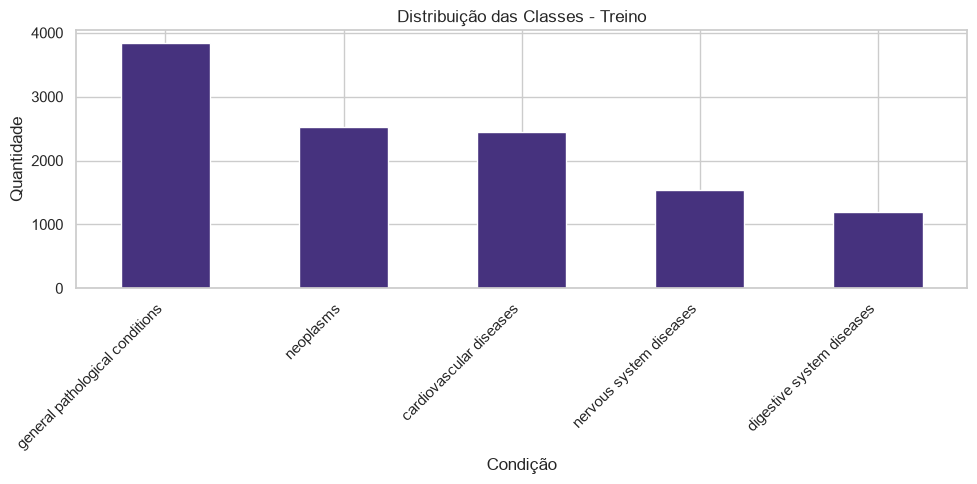

In [12]:
import matplotlib.pyplot as plt

df_train["condition_name"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Distribuição das Classes - Treino")
plt.xlabel("Condição")
plt.ylabel("Quantidade")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
train_dist = df_train["condition_name"].value_counts(normalize=True).mul(100)
test_dist = df_test["condition_name"].value_counts(normalize=True).mul(100)

comparison = pd.DataFrame({
    "Train (%)": train_dist,
    "Test (%)": test_dist
}).round(2)

comparison

,Train (%),Test (%)
condition_name,,
general pathological conditions,33.28,33.28
neoplasms,21.90,21.92
cardiovascular diseases,21.13,21.12
nervous system diseases,13.33,13.33
digestive system diseases,10.35,10.35


### 3.4 Estrutura dos documentos

In [14]:
df_train["word_count"] = df_train["medical_abstract"].str.split().str.len()
df_train["char_count"] = df_train["medical_abstract"].str.len()

df_test["word_count"] = df_test["medical_abstract"].str.split().str.len()
df_test["char_count"] = df_test["medical_abstract"].str.len()

In [15]:
df_train[["word_count", "char_count"]].describe()

,word_count,char_count
count,11550.000000,11550.000000
mean,179.640606,1229.104156
std,76.369776,505.960982
min,24.000000,170.000000
25%,122.000000,847.000000
50%,175.000000,1208.000000
75%,234.000000,1587.000000
max,596.000000,3999.000000


### 3.5 Distribuição do tamanho dos abstracts

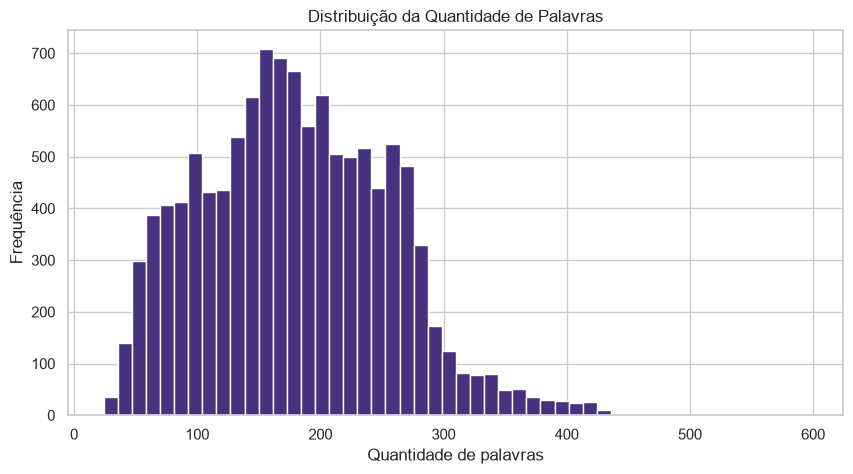

In [16]:
df_train["word_count"].hist(
    bins=50,
    figsize=(10, 5)
)

plt.title("Distribuição da Quantidade de Palavras")
plt.xlabel("Quantidade de palavras")
plt.ylabel("Frequência")
plt.show()

### 3.6 Tamanho dos textos por classe

In [17]:
df_train.groupby("condition_name")["word_count"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
condition_name,,,,,,,,
cardiovascular diseases,2441.0,200.13,80.26,28.0,142.0,205.0,260.0,578.0
digestive system diseases,1195.0,178.66,71.53,30.0,124.0,179.0,227.0,417.0
general pathological conditions,3844.0,177.06,75.75,24.0,120.0,171.0,231.0,528.0
neoplasms,2530.0,174.17,75.10,24.0,119.0,171.0,222.0,422.0
nervous system diseases,1540.0,163.34,70.62,31.0,109.0,158.0,212.0,596.0


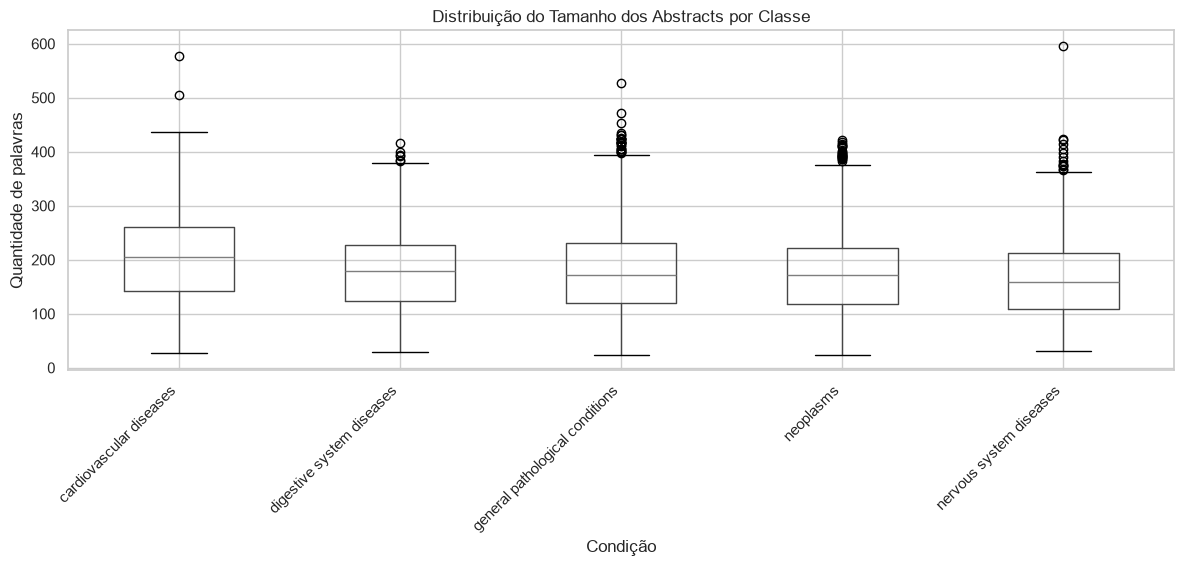

In [18]:
df_train.boxplot(
    column="word_count",
    by="condition_name",
    figsize=(12, 6)
)

plt.title("Distribuição do Tamanho dos Abstracts por Classe")
plt.suptitle("")
plt.xlabel("Condição")
plt.ylabel("Quantidade de palavras")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Textos maiores causam um tratamento maior para o NLP, por terem mais palavras, dando mais chances para ele se confundir, a tokenização se torna a parte mais importante

### 3.7 Palavras mais frequentes

In [19]:
from collections import Counter

words = " ".join(
    df_train["medical_abstract"]
).lower().split()

most_common = Counter(words).most_common(20)

most_common

[('the', 97705),
 ('of', 96673),
 ('and', 64562),
 ('in', 63067),
 ('with', 35024),
 ('a', 34000),
 ('to', 33949),
 ('patients', 22751),
 ('was', 22697),
 ('were', 19270),
 ('for', 17260),
 ('or', 11673),
 ('is', 11658),
 ('by', 11443),
 ('that', 11430),
 ('than', 10536),
 ('from', 8354),
 ('at', 7965),
 ('an', 7874),
 ('this', 7670)]

Quando formos treinar o modelo, provavelmente teremos que tratar essas stopwords, por poder causar confusão no modelo NLP

## 4. Exportando dados tratados

In [20]:
df_train_export = df_train.drop(
    columns=["word_count", "char_count"],
    errors="ignore"
)

df_test_export = df_test.drop(
    columns=["word_count", "char_count"],
    errors="ignore"
)

In [21]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

df_train_export.to_csv(
    "../data/processed/train.csv",
    index=False
)

df_test_export.to_csv(
    "../data/processed/test.csv",
    index=False
)